In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
import seaborn as sns
from scipy.stats import mannwhitneyu

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from PAModelpy.utils import set_up_pam
from Scripts.pam_generation import setup_ecoli_pam as set_up_ecoli_pam_curated
from Modules.utils.sector_config_functions import change_translational_sector_with_config_dict
from Modules.utils.pamparametrizer_analysis import (get_results_from_simulations,
                                                   calculate_error_for_reactions, calculate_r_squared_for_reaction,
                                                   calculate_difference_simulation_experiment)
from Modules.utils.pam_generation import create_pamodel_from_diagnostics_file

# from Modules.utils import calculate_r_squared_for_reaction
# from Scripts.Visualization.PAMparametrizer_progress_cleaned_figure import run_simulations

N_ALT_MODELS = 10
    
ECOLI_PHENOTYPE_DATA_PATH = os.path.join('Data', 'Ecoli_phenotypes')
MODEL_FILE_PATH = os.path.join('Models', 'iML1515.xml')

PARAM_FILE_OLD = os.path.join('Results', '1_preprocessing','proteinAllocationModel_iML1515_EnzymaticData_241209.xlsx')
PARAM_FILE_SCALED = os.path.join('Results', '2_parametrization','proteinAllocationModel_iML1515_EnzymaticData_241209_multi.xlsx')

PARAMETER_RESULT_FILES = [os.path.join('Results','3_analysis','parameter_files',
                                     f'proteinAllocationModel_EnzymaticData_iML1515_{i}.xlsx') for i in range(1,N_ALT_MODELS+1)]
BEST_INDIV_RESULT_FILES = [os.path.join('Results','2_parametrization','diagnostics',
                                     f'pam_parametrizer_diagnostics_{i}_1.xlsx') for i in range(1,N_ALT_MODELS+1)]

Loading PAModelpy modules version 0.0.4.6
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


# 1. Load reference data

In [2]:
# load exchange rates for different carbon sources by Gerosa et al. (2015) in Ecoli BW25113
flux_csources = pd.read_excel(os.path.join(ECOLI_PHENOTYPE_DATA_PATH, 'Ecoli_phenotypes_py.xls'),
                       sheet_name = 'Fluxes_Csources',
                            engine='openpyxl',
                            index_col=1)
flux_csources_df = flux_csources.drop(['Flux (publication)', 'Reversibility'], axis=1)
flux_csources_df.head()

,Acetate,Fructose,Galactose,Glucose,Glycerol,Gluconate,Pyruvate,Succinate,Glucose (flux ratio Glc)
Reaction identifier,,,,,,,,,
EX_ac_e_b,13.584,-3.32866,-1.968939e-08,-6.827019,-0.597000,-5.003982,-11.91391,-3.320974,-0.70717
EX_fru_e_b,0.000,8.32800,0.000000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
EX_gal_e_b,0.000,0.00000,1.969000e+00,0.000000,0.000000,0.000000,0.00000,0.000000,0.00000
EX_glc__D_e_b,0.000,0.00000,0.000000e+00,9.654000,0.000000,0.000000,0.00000,0.000000,1.00000
EX_glyc_e_b,0.000,0.00000,0.000000e+00,0.000000,4.944834,0.000000,0.00000,0.000000,0.00000


# 2. Setup the *Escherichia coli* iML1515 model with new parameters

In [3]:
#setup the model
ecoli_pam_wt = set_up_pam(PARAM_FILE_OLD, 
                          model = MODEL_FILE_PATH, 
                          sensitivity=False) # not curation for reference
ecoli_pam_curated = set_up_ecoli_pam_curated(
    pam_data_file_path = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),
    sensitivity = False) # curated for reference

pam = set_up_pam(PARAM_FILE_SCALED, 
                 model = MODEL_FILE_PATH,
                 sensitivity = False)
pam.change_reaction_bounds('EX_glc__D_e', lower_bound=0)

new_ecoli_pams = {alt+1: create_pamodel_from_diagnostics_file(file,
                                          pam.copy(copy_with_pickle=True)) for alt, file in enumerate(BEST_INDIV_RESULT_FILES)}

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector



/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:245: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector

Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedEnzymeSector

Done with setting up the proteome allocation model iML1515



# 3. Check internal flux distribution

## 3.1 Parse dataframes to validate the flux distribution

In [4]:
# Get the data for growth on multiple carbon sources from Gerosa et al. (2015)
# Make sure all the fluxes of backward reactions are inverted to match the model directionality
fluxes_to_simulate = flux_csources_df.copy()
new_indices = []
for i, row in fluxes_to_simulate.iterrows():
    if isinstance(row.name, str):
        if row.name[-2:] == '_b':
            new_indices.append(row.name[:-2])
            fluxes_to_simulate.loc[row.name]= -row
        else: 
            new_indices.append(row.name)
    else:
        new_indices.append(row.name)
            
fluxes_to_simulate.index = new_indices
fluxes_to_simulate_parsed = fluxes_to_simulate[fluxes_to_simulate.index.notnull()]
fluxes_to_simulate_parsed = fluxes_to_simulate_parsed.rename(
    index = {'BIOMASS_Ec_iML1515_WT_75p37M':'BIOMASS_Ecoli_core_w_GAM'}
).drop('Glucose (flux ratio Glc)', axis = 1)

In [5]:
# extract the validation data and substrate information for each carbon source
flux_mapper = {col: fluxes_to_simulate_parsed.index[i] for i,col in enumerate(fluxes_to_simulate_parsed.columns)}
fluxes_to_save = []
# Get the fluxes we want to save
for flux in fluxes_to_simulate_parsed.index:
    if isinstance(flux, str):
        fluxes_to_save += [f for f in flux.split(', ')]

#parse the fluxes such that we can run and validate simulations easily
validation_df = pd.DataFrame(columns = list(fluxes_to_simulate_parsed.index))
substrate_ids = []
substrate_uptake = []
for substrate, fluxes in fluxes_to_simulate_parsed.items():
    substrate_ids += [flux_mapper[substrate]]
    substrate_uptake += [fluxes.loc[flux_mapper[substrate]]]
    validation_df = pd.concat([validation_df,fluxes.to_frame().T], ignore_index =True)

validation_df.index = list(flux_mapper.values())
validation_df

,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,TKT2,PPC,PPCK,ICDHyr,SUCDi,FUM,"MDH, MDH2, MDH3","ME1, ME2",ICL,BIOMASS_Ec_iML1515_core_75p37M
EX_ac_e,-1.358400e+01,-0.000,-0.000,-0.000,-0.000000,-0.000000,-0.000,-0.000,1.358425e-07,0.00000,...,0.718249,1.774145,3.114281e+00,4.696417,8.404765,8.404765,10.671300,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.328660e+00,-8.328,-0.000,-0.000,-0.000000,-0.000000,-0.000,-0.000,8.327452e-08,0.00000,...,1.788933,3.545669,3.589203e-01,4.566119,3.877105,3.877105,2.227706,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,1.968939e-08,-0.000,-1.969,-0.000,-0.000000,-0.000000,-0.000,-0.000,1.968946e-08,0.00000,...,0.058569,0.377386,8.489495e-01,0.496177,1.260858,1.260858,2.285119,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.827019e+00,-0.000,-0.000,-9.654,-0.000000,-0.000000,-0.000,-0.000,9.653732e-08,0.00000,...,0.584644,2.453331,5.408740e-01,2.977971,2.138073,2.138073,2.138073,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,5.970003e-01,-0.000,-0.000,-0.000,-4.944834,-0.000000,-0.000,-0.000,1.013568e-07,0.00000,...,0.904380,1.376469,-1.003518e-07,2.464836,1.840459,1.840459,1.840459,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.003982e+00,-0.000,-0.000,-0.000,-0.000000,-7.283923,-0.000,-0.000,7.283677e-08,0.00000,...,0.170985,1.943350,-7.211081e-08,1.154034,0.182358,0.182358,0.182358,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,1.191391e+01,-0.000,-0.000,-0.000,-0.000000,-0.000000,-26.714,-0.000,0.000000e+00,1.15701,...,0.090131,2.489449,1.164803e+00,7.979320,7.518256,7.518256,7.427797,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.320974e+00,-0.000,-0.000,-0.000,-0.000000,-0.000000,-0.000,-15.902,1.139998e+00,0.00000,...,1.369847,2.016110,2.971789e+00,3.038949,18.370434,17.230436,4.950705,1.239618e+01,1.164515e-01,0.5100


## 3.2 Run simulations

In [6]:
kwargs = {'substrate_ids': list(validation_df.index), 
          'substrate_rates': [[rate] for rate in substrate_uptake],
          'fluxes_to_save' : fluxes_to_save}
# for each study, run simulations
fluxes_curated = get_results_from_simulations(ecoli_pam_curated, **kwargs)['fluxes']
print('\n')
fluxes_wt = get_results_from_simulations(ecoli_pam_wt,**kwargs)['fluxes']
print('\n')
# fluxes_new = run_simulations(ecoli_pam_new, **kwargs)

for alt, pam in new_ecoli_pams.items():
    pam.change_reaction_bounds('EX_glc__D_e', 0, 1e3)
    new_ecoli_pams[alt] = pam

fluxes_new_dict = {alt: get_results_from_simulations(pam, **kwargs)['fluxes'] for alt, pam in new_ecoli_pams.items()}

Running simulations with -13.58 mmol/g_cdw/h of substrate (EX_ac_e) going into the system
Running simulations with -8.33 mmol/g_cdw/h of substrate (EX_fru_e) going into the system
Running simulations with -1.97 mmol/g_cdw/h of substrate (EX_gal_e) going into the system
Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the system
Running simulations with -26.71 mmol/g_cdw/h of substrate (EX_pyr_e) going into the system
Running simulations with -15.9 mmol/g_cdw/h of substrate (EX_succ_e) going into the system


Running simulations with -13.58 mmol/g_cdw/h of substrate (EX_ac_e) going into the system
Running simulations with -8.33 mmol/g_cdw/h of substrate (EX_fru_e) going into the system
Running simulations with -1.97 mmol/g_cdw/h of substrate (EX_gal_e) going into the system
R

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the system
Running simulations with -26.71 mmol/g_cdw/h of substrate (EX_pyr_e) going into the system
Running simulations with -15.9 mmol/g_cdw/h of substrate (EX_succ_e) going into the system
Running simulations with -13.58 mmol/g_cdw/h of substrate (EX_ac_e) going into the system
Running simulations with -8.33 mmol/g_cdw/h of substrate (EX_fru_e) going into the system
Running simulations with -1.97 mmol/g_cdw/h of substrate (EX_gal_e) going into the system
Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the syste

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the system
Running simulations with -26.71 mmol/g_cdw/h of substrate (EX_pyr_e) going into the system
Running simulations with -15.9 mmol/g_cdw/h of substrate (EX_succ_e) going into the system
Running simulations with -13.58 mmol/g_cdw/h of substrate (EX_ac_e) going into the system
Running simulations with -8.33 mmol/g_cdw/h of substrate (EX_fru_e) going into the system
Running simulations with -1.97 mmol/g_cdw/h of substrate (EX_gal_e) going into the system
Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the syste

...

Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the system
Running simulations with -26.71 mmol/g_cdw/h of substrate (EX_pyr_e) going into the system
Running simulations with -15.9 mmol/g_cdw/h of substrate (EX_succ_e) going into the system
Running simulations with -13.58 mmol/g_cdw/h of substrate (EX_ac_e) going into the system
Running simulations with -8.33 mmol/g_cdw/h of substrate (EX_fru_e) going into the system
Running simulations with -1.97 mmol/g_cdw/h of substrate (EX_gal_e) going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the system
Running simulations with -26.71 mmol/g_cdw/h of substrate (EX_pyr_e) going into the system
Running simulations with -15.9 mmol/g_cdw/h of substrate (EX_succ_e) going into the system
Running simulations with -13.58 mmol/g_cdw/h of substrate (EX_ac_e) going into the system
Running simulations with -8.33 mmol/g_cdw/h of substrate (EX_fru_e) going into the system
Running simulations with -1.97 mmol/g_cdw/h of substrate (EX_gal_e) going into the system
Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the syste

/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


Running simulations with -9.65 mmol/g_cdw/h of substrate (EX_glc__D_e) going into the system
Running simulations with -4.94 mmol/g_cdw/h of substrate (EX_glyc_e) going into the system
Running simulations with -7.28 mmol/g_cdw/h of substrate (EX_glcn_e) going into the system
Running simulations with -26.71 mmol/g_cdw/h of substrate (EX_pyr_e) going into the system
Running simulations with -15.9 mmol/g_cdw/h of substrate (EX_succ_e) going into the system


In [7]:
#calculate R^2 value between simulations and experiments
error_curated = calculate_error_for_reactions(validation_df,
                                                 fluxes_curated,
                                                 fluxes_to_save)
print('R^2 values for the model with published parameter set :', np.nanmean(error_curated))

error_wt = calculate_error_for_reactions(validation_df,
                                                 fluxes_wt,
                                                 fluxes_to_save[1:])
print('R^2 values for the model with parameters from GotEnzymes: ', np.nanmean(error_wt))


# error_new = calculate_error_for_reactions(validation_df,
#                                                  fluxes_new,
#                                                  fluxes_to_save[1:])
error_new_dict = {alt: calculate_error_for_reactions(validation_df,
                                                  fluxes,
                                                  fluxes_to_save[1:]) for alt, fluxes in fluxes_new_dict.items()}
for alt, error_list in error_new_dict.items():
    print(f'R^2 values for alternative model {alt} with the optimized parameters: ', np.nanmean(error_list))



R^2 values for the model with published parameter set : -3.4951994946375637
R^2 values for the model with parameters from GotEnzymes:  -15.806640722845426
R^2 values for alternative model 1 with the optimized parameters:  -3.01750016640358
R^2 values for alternative model 2 with the optimized parameters:  -0.03826532697204951
R^2 values for alternative model 3 with the optimized parameters:  -3.01750016640358
R^2 values for alternative model 4 with the optimized parameters:  -0.03826532697204951
R^2 values for alternative model 5 with the optimized parameters:  -3.01750016640358
R^2 values for alternative model 6 with the optimized parameters:  -3.01750016640358
R^2 values for alternative model 7 with the optimized parameters:  -3.01750016640358
R^2 values for alternative model 8 with the optimized parameters:  -0.03826532697204951
R^2 values for alternative model 9 with the optimized parameters:  -0.03826532697204951
R^2 values for alternative model 10 with the optimized parameters:  

## 3.2 Visualize the simulation results for the different models

In [8]:
# validation_df_1.index = validation_df.index.str.split(', ')
validation_df_1 = validation_df.T.reset_index()
validation_df_1['index'] = validation_df_1['index'].str.split(', ')
validation_df_1 = validation_df_1.explode('index').set_index('index').T
validation_df_1
# validation_df = validation_df.explode()

index,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,ICDHyr,SUCDi,FUM,MDH,MDH2,MDH3,ME1,ME2,ICL,BIOMASS_Ec_iML1515_core_75p37M
EX_ac_e,13.5840,0.000,0.000,0.000,0.0000,0.0000,0.000,0.000,1.358425e-07,0.00000,...,4.696417,8.404765,8.404765,10.671300,10.671300,10.671300,1.871037e+00,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.3287,8.328,0.000,0.000,0.0000,0.0000,0.000,0.000,8.327452e-08,0.00000,...,4.566119,3.877105,3.877105,2.227706,2.227706,2.227706,1.651610e+00,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,0.0000,0.000,1.969,0.000,0.0000,0.0000,0.000,0.000,1.968946e-08,0.00000,...,0.496177,1.260858,1.260858,2.285119,2.285119,2.285119,5.237651e-04,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.8270,0.000,0.000,9.654,0.0000,0.0000,0.000,0.000,9.653732e-08,0.00000,...,2.977971,2.138073,2.138073,2.138073,2.138073,2.138073,-9.557242e-08,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,0.5970,0.000,0.000,0.000,4.9448,0.0000,0.000,0.000,1.013568e-07,0.00000,...,2.464836,1.840459,1.840459,1.840459,1.840459,1.840459,-1.003463e-07,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.0040,0.000,0.000,0.000,0.0000,7.2839,0.000,0.000,7.283677e-08,0.00000,...,1.154034,0.182358,0.182358,0.182358,0.182358,0.182358,-7.210584e-08,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,11.9139,0.000,0.000,0.000,0.0000,0.0000,26.714,0.000,0.000000e+00,1.15701,...,7.979320,7.518256,7.518256,7.427797,7.427797,7.427797,1.930607e-01,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.3210,0.000,0.000,0.000,0.0000,0.0000,0.000,15.902,1.139998e+00,0.00000,...,3.038949,18.370434,17.230436,4.950705,4.950705,4.950705,1.239618e+01,1.239618e+01,1.164515e-01,0.5100


In [9]:
validation_df

,EX_ac_e,EX_fru_e,EX_gal_e,EX_glc__D_e,EX_glyc_e,EX_glcn_e,EX_pyr_e,EX_succ_e,EX_fum_e,EX_lac_e,...,TKT2,PPC,PPCK,ICDHyr,SUCDi,FUM,"MDH, MDH2, MDH3","ME1, ME2",ICL,BIOMASS_Ec_iML1515_core_75p37M
EX_ac_e,13.5840,0.000,0.000,0.000,0.0000,0.0000,0.000,0.000,1.358425e-07,0.00000,...,0.718249,1.774145,3.114281e+00,4.696417,8.404765,8.404765,10.671300,1.871037e+00,4.137602e+00,0.2900
EX_fru_e,3.3287,8.328,0.000,0.000,0.0000,0.0000,0.000,0.000,8.327452e-08,0.00000,...,1.788933,3.545669,3.589203e-01,4.566119,3.877105,3.877105,2.227706,1.651610e+00,2.210442e-03,0.4924
EX_gal_e,0.0000,0.000,1.969,0.000,0.0000,0.0000,0.000,0.000,1.968946e-08,0.00000,...,0.058569,0.377386,8.489495e-01,0.496177,1.260858,1.260858,2.285119,5.237651e-04,1.024785e+00,0.1800
EX_glc__D_e,6.8270,0.000,0.000,9.654,0.0000,0.0000,0.000,0.000,9.653732e-08,0.00000,...,0.584644,2.453331,5.408740e-01,2.977971,2.138073,2.138073,2.138073,-9.557242e-08,9.654038e-10,0.6500
EX_glyc_e,0.5970,0.000,0.000,0.000,4.9448,0.0000,0.000,0.000,1.013568e-07,0.00000,...,0.904380,1.376469,-1.003518e-07,2.464836,1.840459,1.840459,1.840459,-1.003463e-07,1.013606e-09,0.4900
EX_glcn_e,5.0040,0.000,0.000,0.000,0.0000,7.2839,0.000,0.000,7.283677e-08,0.00000,...,0.170985,1.943350,-7.211081e-08,1.154034,0.182358,0.182358,0.182358,-7.210584e-08,7.284001e-08,0.5900
EX_pyr_e,11.9139,0.000,0.000,0.000,0.0000,0.0000,26.714,0.000,0.000000e+00,1.15701,...,0.090131,2.489449,1.164803e+00,7.979320,7.518256,7.518256,7.427797,1.930607e-01,1.026014e-01,0.3900
EX_succ_e,3.3210,0.000,0.000,0.000,0.0000,0.0000,0.000,15.902,1.139998e+00,0.00000,...,1.369847,2.016110,2.971789e+00,3.038949,18.370434,17.230436,4.950705,1.239618e+01,1.164515e-01,0.5100


### experiment vs simulation scatterplot

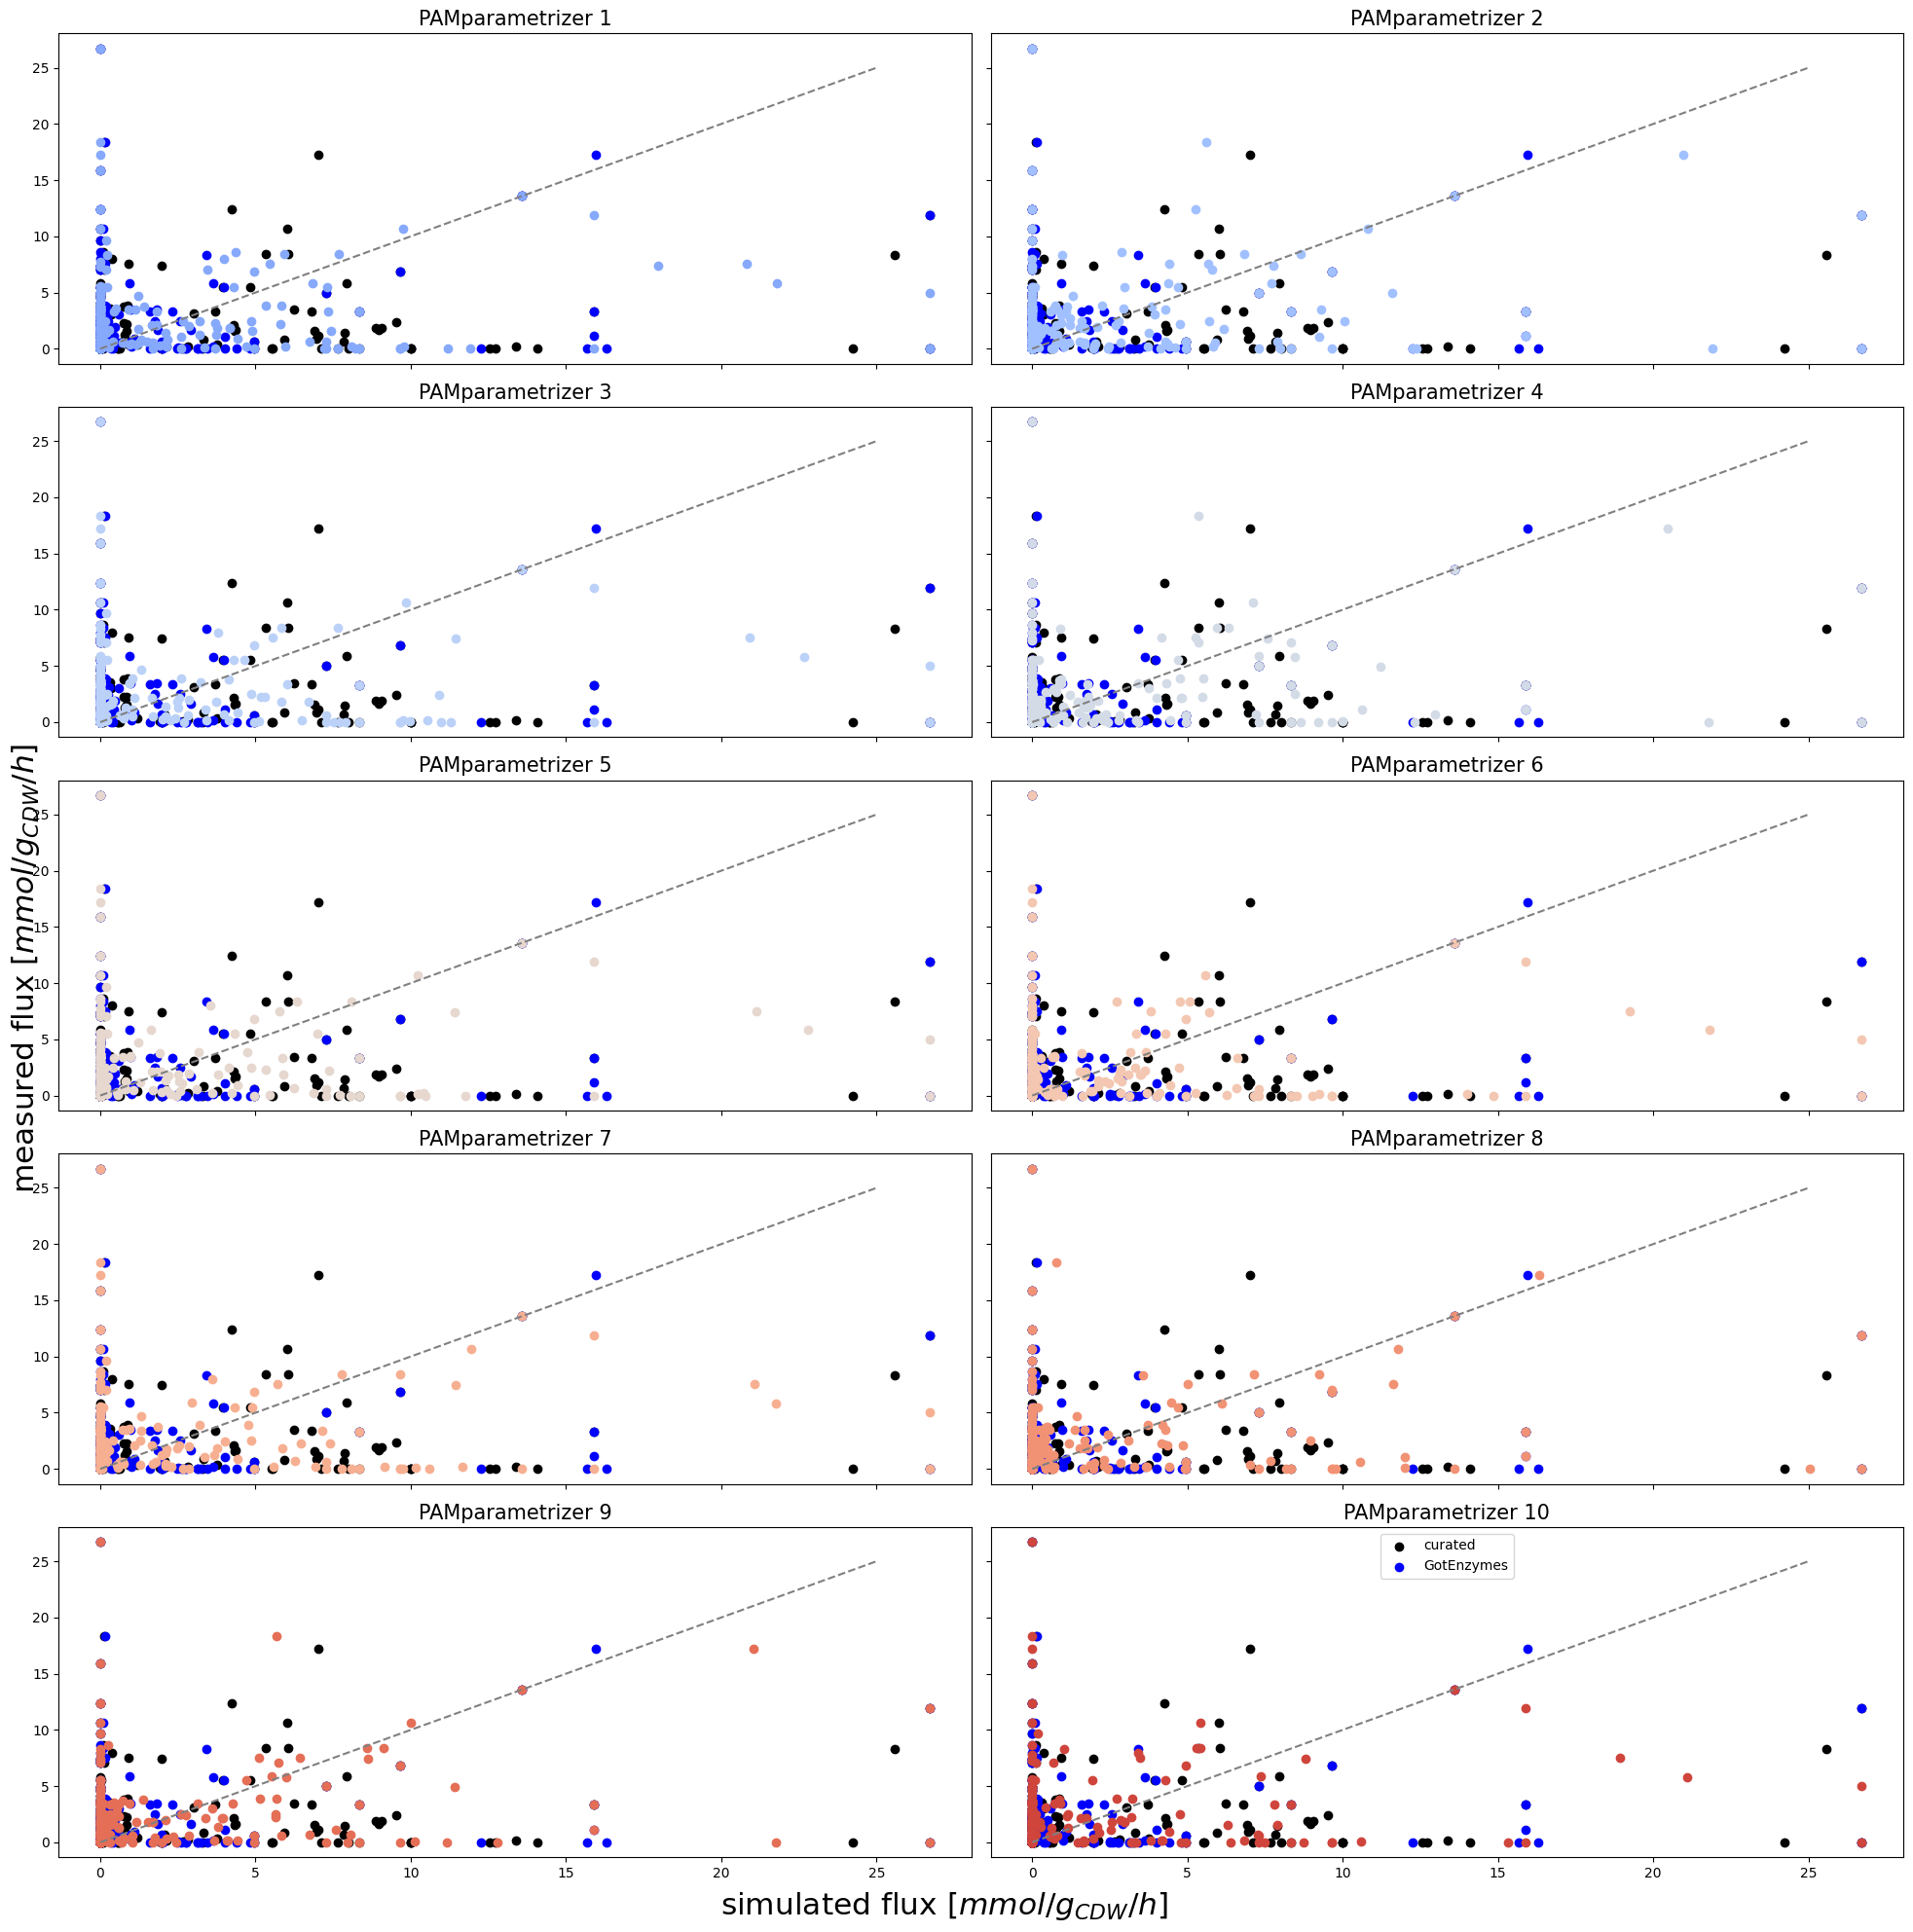

In [10]:
models = ['GotEnzymes','Curated'] + [f'PAMparametrizer {alt}' for alt in range(1,N_ALT_MODELS+1)]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))
fontsize=15

fig, axs = plt.subplots(nrows = int(len(fluxes_new_dict)/2), ncols = 2, sharey='row', sharex='col', figsize = (20,20))
axs = axs.flatten()

for alt, fluxes_new in fluxes_new_dict.items():
    ax = axs[alt-1]
    curated = []
    wt = []
    new = []
    validation = []
    for i in range(len(fluxes_curated)):
        curated += [abs(flx) for flx in fluxes_curated.iloc[i].to_list()[1:-1]]
        if i<len(fluxes_wt):
            wt += [abs(flx) for flx in fluxes_wt.iloc[i].to_list()[1:-1]]
        else:
            wt += [0]*len(fluxes_curated.iloc[i].to_list()[1:-1])
        if i<len(fluxes_new):
            new += [abs(flx) for flx in fluxes_new.iloc[i].to_list()[1:-1]]
        else:
            new += [0]*len(fluxes_curated.iloc[i].to_list()[1:-1])
        validation += validation_df_1.iloc[i].abs().to_list()
    
    ax.plot([0,25], [0,25], linestyle = 'dashed', color='grey')
    ax.scatter(curated, validation, label = 'curated', color = 'black')
    ax.scatter(wt, validation, label = 'GotEnzymes', color ='blue')
    ax.scatter(new, validation, color = cmap[f'PAMparametrizer {alt}'])#, label = f'PAMparametrizer {alt}'
    ax.set_title(f'PAMparametrizer {alt}', fontsize = fontsize)

fig.supxlabel('simulated flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
fig.supylabel('measured flux [$mmol/g_{CDW}/h$]', fontsize = fontsize*1.5)
plt.legend()

plt.tight_layout()
plt.show()

### Boxplots of simulation error

In [11]:
def plot_significant_annotation(ax, column, sign, compare_df, dodge_factor):
        # Add annotation for significance
        x1, x2 = 1, column
        start = compare_df.Difference.quantile(0.865) +0.65
        y, h = compare_df.Difference.quantile(0.865)+ dodge_factor, 0.75  # Dynamically adjust y position
        ax.plot([x1, x1, x2, x2], [y, y+h, y+h, start], lw=1.5, color='k')
        ax.text((x1 + x2) * 0.5, y + h*0.6, sign, ha='center', va='bottom', fontsize=fontsize, color='k')

/tmp/ipykernel_987216/2423137025.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)
/tmp/ipykernel_987216/2423137025.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)


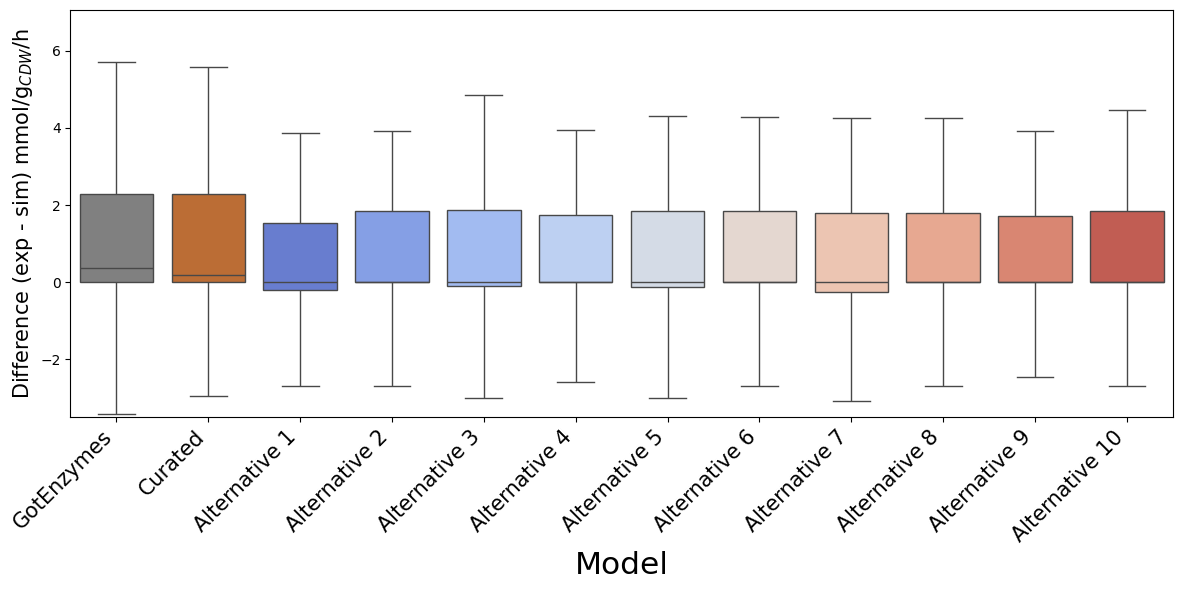

In [22]:
fontsize = 15
models = [f'Alternative {alt}' for alt in error_new_dict.keys()]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))
cmap = {**cmap,**{'GotEnzymes': 'grey', 'Curated': 'chocolate'}}

# Prepare the figure
fig, ax = plt.subplots(figsize=(12, 6))

# Combine data into a DataFrame
all_differences = pd.DataFrame()
curated_differences = None  # Placeholder for Curated errors
num_significant = 0

for col, (model, sub_df) in enumerate(zip(['GotEnzymes', 'Curated']+models, [fluxes_wt, fluxes_curated] + list(fluxes_new_dict.values()))):
    differences = []
    for _, row in sub_df.iterrows():
        substrate_id = row['substrate_id']
        difference = calculate_difference_simulation_experiment(
            validation_df_1, row, fluxes_to_save[1:], substrate_id)
        differences += difference

    temp_df = pd.DataFrame({'Model': [model] * len(differences), 'Difference': differences})
    
    # Store curated differences for comparison
    if model == 'GotEnzymes':
        curated_differences = differences
        curated_diff_df = temp_df[temp_df.Model == 'GotEnzymes']
#     elif 'PAMparametrizer' in model or 'alternative' in model:
#         # Statistical test
#         stat, p = mannwhitneyu(curated_differences, differences, alternative='greater')
#         print(f"{model}: U-statistic = {stat}, p-value = {p}")
# #         if p < 0.075:
# #             sign = '*'
# #         if p < 0.05:
# #             sign = '**'
#         if p < 0.01:
#             sign = '*'
# #         if p < 0.075:
#             num_significant += 1
#             plot_significant_annotation(ax, col, sign, curated_diff_df, 1+num_significant*0.65)

    # Append to the main DataFrame
    all_differences = pd.concat([all_differences, temp_df], ignore_index=True)

# Boxplot or Violin Plot
sns.boxplot(x='Model', y='Difference', data=all_differences, ax=ax, palette=cmap, showfliers=False)

# Adjust y-axis to focus on bulk data and add space for annotations
ax.set_ylim([all_differences['Difference'].quantile(0.05), all_differences['Difference'].quantile(0.94)])

# Set labels and title
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=fontsize)
ax.set_xlabel('Model', fontsize=fontsize * 1.5)
ax.set_ylabel(r'Difference (exp - sim) mmol/$\text{g}_{CDW}$/h', fontsize=fontsize)

plt.tight_layout()
# plt.show()
plt.savefig('Results/3_analysis/multiple_csources_error_boxplot.png')

### Histograms of simulation error

/tmp/ipykernel_987216/2115332874.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, palette=cmap, ax=ax[2])
/tmp/ipykernel_987216/2115332874.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, palette=cmap, ax=ax[2])
/tmp/ipykernel_987216/2115332874.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='Difference', data=all_differences, palette=cmap, ax=ax[2])
/tmp/ipykernel_987216/2115332874.py:15: FutureWarning: 

Pass

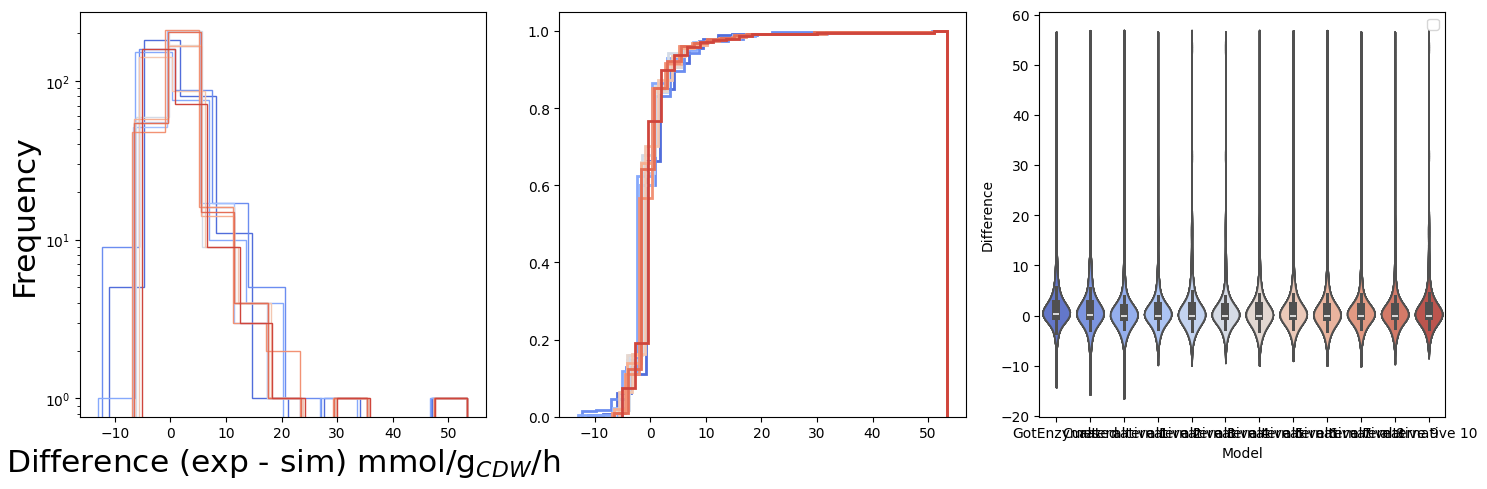

In [13]:
models = ['GotEnzymes','Curated'] + [f'alternative {alt}' for alt in error_new_dict.keys()]
model_colors = sns.color_palette("coolwarm", n_colors=len(models))
cmap = dict(zip(models, model_colors))
n_bins=25

fig, ax = plt.subplots(ncols = 3,figsize=(15, 5), dpi=100)
row = -1

for model in models:
    data = all_differences[all_differences.Model == model]
    
    ax[0].hist(data.Difference, label = model, color = to_hex(cmap[model]), histtype = 'step')#histogram
    ax[1].hist(data.Difference, bins=n_bins, cumulative=True, density=True, histtype='step', 
            label=model, color=to_hex(cmap[model]), linewidth=2) #cumulative histogram
    sns.violinplot(x='Model', y='Difference', data=all_differences, palette=cmap, ax=ax[2])


# Set labels and title
ax[0].set_yscale('log')
ax[0].set_xlabel(r'Difference (exp - sim) mmol/$\text{g}_{CDW}$/h', fontsize=fontsize * 1.5)
ax[0].set_ylabel('Frequency', fontsize=fontsize * 1.5)

plt.legend()
plt.tight_layout()
plt.show()

### Kernel density plot
A Kernel Density Plot (KDE Plot) is a statistical tool used to estimate the probability density function of a continuous variable. It provides a smooth, continuous curve that represents the distribution of your data, offering a visualization of where data points are concentrated.


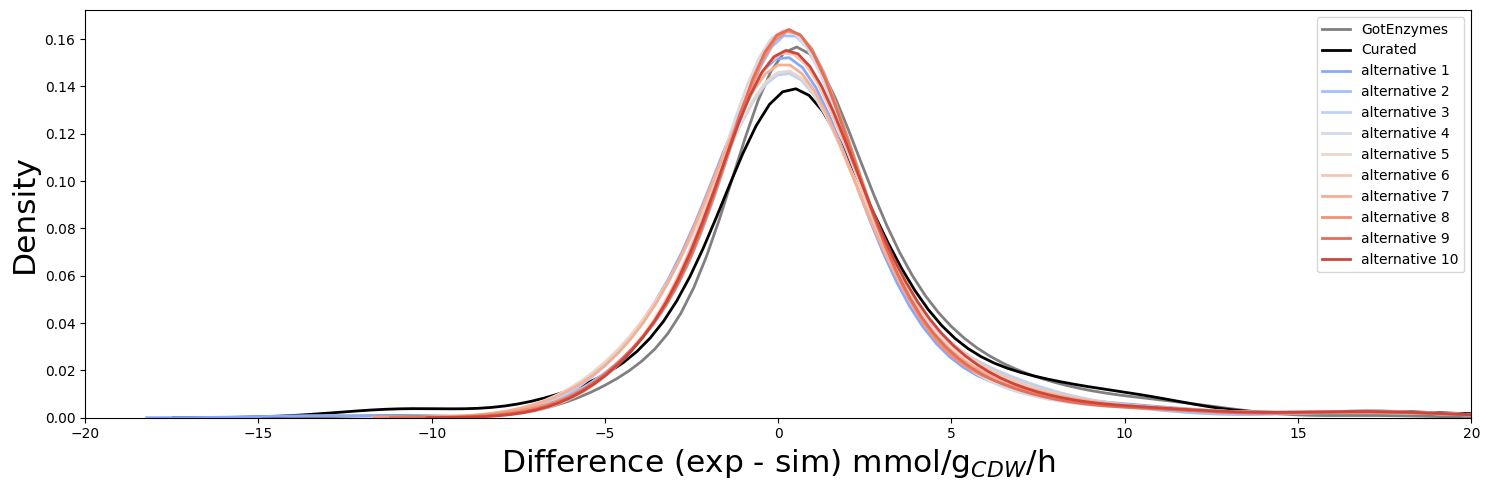

In [14]:
fig, ax = plt.subplots(figsize=(15, 5), dpi=100)

for model in models:
    data = all_differences[all_differences.Model == model]['Difference']
    if model == 'Curated': color = 'black'
    elif model == 'GotEnzymes': color = 'grey'
    else: color = to_hex(cmap[model])
    sns.kdeplot(data, ax=ax, label=model, color=color, linewidth=2)

# Set labels and title
ax.set_xlabel(r'Difference (exp - sim) mmol/$\text{g}_{CDW}$/h', fontsize=fontsize * 1.5)
ax.set_ylabel('Density', fontsize=fontsize * 1.5)
ax.set_xlim([-20,20])
ax.legend()
plt.tight_layout()
plt.show()

### line graphs of simulation per reaction

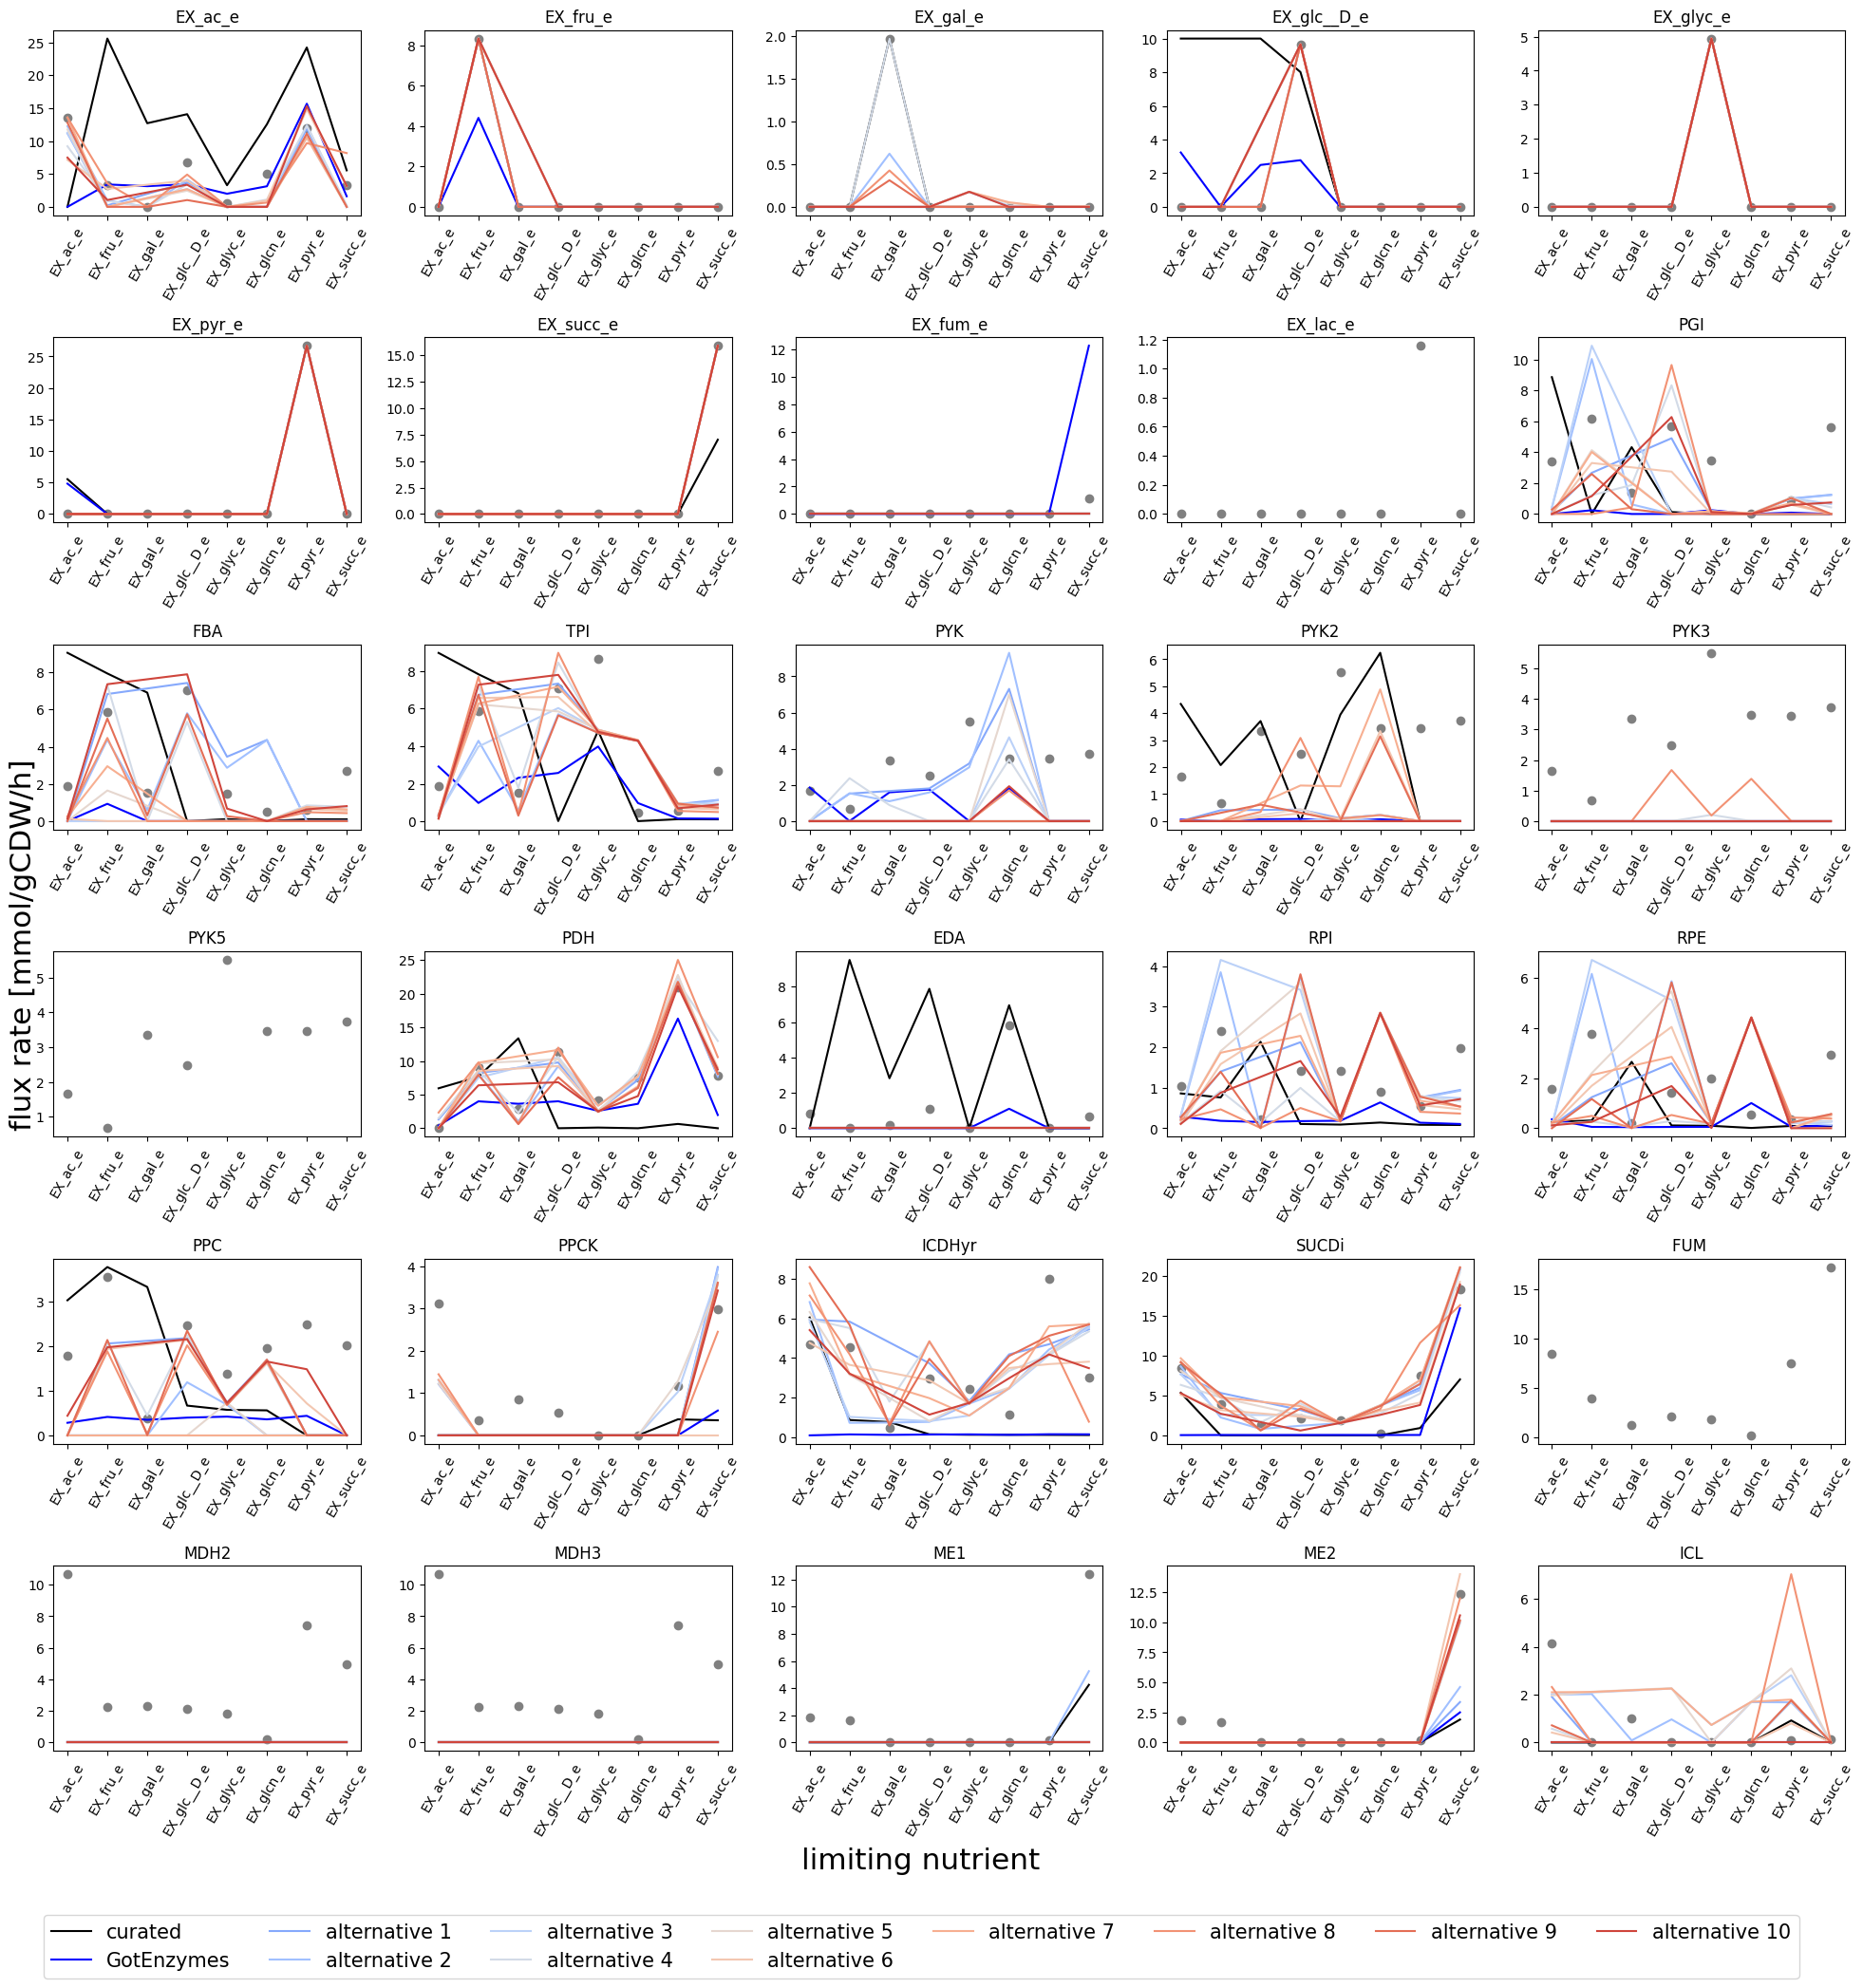

In [15]:
# visualize per flux
fig, axs = plt.subplots(ncols = 5, nrows = 6, figsize = [20,20])
substrate_ids_cur = fluxes_curated.substrate_id
substrate_ids = fluxes_new_dict[1].substrate_id


#make the plot panels for each reaction
fig_reactions = []
for i in range(0,36,6):
    fig_reactions += [[rxn for rxn in fluxes_to_save[i:i+5]]]
# plot all reactions
for j in range(6):
    reactions_to_plot = fig_reactions[j]
    for i, rxn in enumerate(reactions_to_plot):
        validation = validation_df_1[rxn]
        axs[j,i].scatter(substrate_ids_cur, validation_df_1.loc[substrate_ids_cur, rxn].abs(), color = 'grey')
        axs[j,i].plot(substrate_ids_cur, fluxes_curated[rxn].abs(), label = 'curated', color = 'black')
        axs[j,i].plot(fluxes_wt['substrate_id'], fluxes_wt[rxn].abs(),label = 'GotEnzymes', color = 'blue')
        for alt, fluxes in fluxes_new_dict.items():
            axs[j,i].plot(fluxes['substrate_id'], fluxes[rxn].abs(), label = f'alternative {alt}', 
                          color = cmap[f'alternative {alt}'])

#         axs[j,i].plot(substrate_ids, fluxes_new[rxn].abs(), label = 'PAMparametrizer', color = 'red')
        axs[j,i].set_title(rxn)
        axs[j,i].tick_params(axis='x', labelrotation=60)

        
# Shrink current axis's height by 10% on the bottom
box = axs[j,i].get_position()
axs[j,i].set_position([box.x0, box.y0 + box.height * 0.1,
                 box.width, box.height * 0.9])
        

handles, labels = axs[j,i].get_legend_handles_labels()    
fig.legend(handles, labels, loc = 'lower center', bbox_to_anchor=(0.5, -0.05),ncols = 8, fontsize= fontsize)

fig.supylabel('flux rate [mmol/gCDW/h]', fontsize = fontsize*1.5)
fig.supxlabel('limiting nutrient', fontsize = fontsize*1.5)

plt.tight_layout()

plt.show()